## Transformer implementation on toy data

In [ ]:
# imports

import torch
import torch.nn as nn 
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

import sys
from pathlib import Path

sys.path.append(str(Path("..").resolve()))

# module imports


In [3]:
print(torch.__version__)
print(torch.version.cuda)
print(torch.cuda.is_available())

2.8.0+cu128
12.8
True


In [10]:
# what the toy data looks like
from src.utils import load_toy

(train, test), (i2c, c2i) = load_toy(final=False)

print("".join([i2c[idx] for idx in train[:100]]))

the short man goes ( for the gorgeous bear ) . the koala walks to the lawyer . a willowy businesswom


### 1) Baseline: MLP

In [ ]:
from src.train_baseline import run

train_loss, val_loss, val_acc, model, test_acc, sampled_sentence = run()

cuda
[2.8935361981391905, 2.407325732707977, 2.0559617638587953, 1.9158748996257782, 1.7446436709165574, 1.5614109206199647, 1.4343880712985992, 1.331254723072052, 1.1894360223412515, 1.0758777660131456, 0.986791278719902, 0.8672560867667198, 0.8478785300254822, 0.8302545329928398, 0.7596307536959648, 0.7064221459627151, 0.7146188285946846, 0.6848134136199951, 0.6947874408960343, 0.6505873522162438]
[2.557373809814453, 2.298511213064194, 1.9916839361190797, 1.836072438955307, 1.6138760089874267, 1.4697982728481294, 1.4649179756641388, 1.261798295378685, 1.2067024081945419, 1.1040836334228517, 1.1658946692943573, 1.1943810313940049, 1.032027368247509, 0.9059614643454552, 0.7843565076589585, 0.7784771785140038, 0.8661148115992546, 0.6820521235466004, 0.745252725481987, 0.546822102367878]
[0.284375, 0.315625, 0.440625, 0.459375, 0.48125, 0.553125, 0.53125, 0.615625, 0.615625, 0.634375, 0.646875, 0.61875, 0.65625, 0.70625, 0.740625, 0.728125, 0.734375, 0.76875, 0.76875, 0.8375]
test loss: 

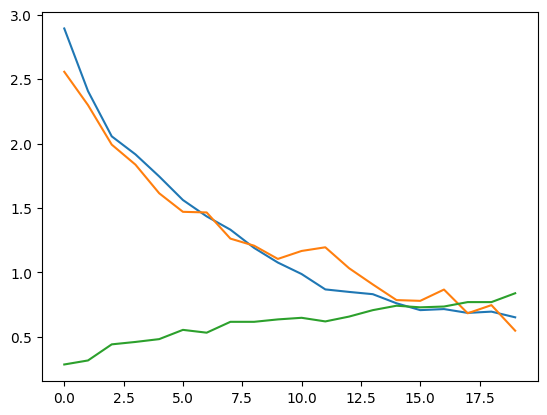

In [11]:
# plot results

plt.plot(train_loss)
plt.plot(val_loss)
plt.plot(val_acc)

## 2) Transformer

In [ ]:
# 